# 02 — Filter-Bank CSP (FBCSP)

CSP extended across several mu/beta sub-bands. Per-band log-variance features are stacked, then `SelectKBest(f_classif)` trims to the most informative filters before LDA. Typically a few F1 points above plain CSP on motor imagery.

Note: this notebook **bypasses** the notebook-wide 8–30 Hz bandpass applied in `load_xdf_epochs` — we pass `band=(1, 45)` and re-filter per sub-band.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import joblib
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt
from mne.decoding import CSP
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

from utils.data import load_xdf_epochs, SRATE_DEFAULT
from utils.eval import cv_score, save_result, RESULTS_DIR
from utils.plot import plot_confusion

# Wide band so per-sub-band filters see an unaltered signal.
X, y, classes = load_xdf_epochs('../visionpro-ml.xdf', band=(1.0, 45.0))
print('X:', X.shape, ' y:', y.shape, ' classes:', classes)

X: (90, 4, 625)  y: (90,)  classes: {0: 'left', 1: 'right', 2: 'both'}


In [2]:
SUBBANDS = [(8, 12), (12, 16), (16, 22), (22, 30)]

class FBCSP(BaseEstimator, TransformerMixin):
    def __init__(self, bands=SUBBANDS, srate=SRATE_DEFAULT, n_components=4):
        self.bands = bands
        self.srate = srate
        self.n_components = n_components

    def _bp(self, X, lo, hi):
        nyq = 0.5 * self.srate
        b, a = butter(4, [lo / nyq, hi / nyq], btype='band')
        return filtfilt(b, a, X, axis=-1)

    def fit(self, X, y):
        self.csps_ = []
        for lo, hi in self.bands:
            Xb = self._bp(X, lo, hi)
            csp = CSP(n_components=self.n_components, reg='ledoit_wolf',
                      log=True, norm_trace=False)
            csp.fit(Xb, y)
            self.csps_.append(csp)
        return self

    def transform(self, X):
        feats = []
        for (lo, hi), csp in zip(self.bands, self.csps_):
            feats.append(csp.transform(self._bp(X, lo, hi)))
        return np.concatenate(feats, axis=1)

In [3]:
def make_pipeline(k=8, n_components=4):
    return Pipeline([
        ('fbcsp', FBCSP(bands=SUBBANDS, srate=SRATE_DEFAULT,
                        n_components=n_components)),
        ('select', SelectKBest(f_classif, k=k)),
        ('lda', LinearDiscriminantAnalysis()),
    ])

def fit_predict(X_tr, y_tr, X_val, y_val):
    pipe = make_pipeline(k=8, n_components=4)
    pipe.fit(X_tr, y_tr)
    return pipe.predict(X_val)

result = cv_score(fit_predict, X, y, n_splits=5, seed=42)
print(f"accuracy  : {result['accuracy']:.3f} ± {result['accuracy_std']:.3f}")
print(f"f1 macro  : {result['f1_macro']:.3f} ± {result['f1_macro_std']:.3f}")
print(f"per-class : {dict(zip(classes.values(), [round(v,3) for v in result['per_class_f1']]))}")

Computing rank from data with rank=None


    Using tolerance 0.072 (2.2e-16 eps * 4 dim * 8.1e+13  max singular value)


    Estimated rank (data): 4


    data: rank 4 computed from 4 data channels with 0 projectors


Reducing data rank from 4 -> 4


...

Estimating class=1 covariance using LEDOIT_WOLF


Done.


Estimating class=2 covariance using LEDOIT_WOLF


Done.


accuracy  : 0.344 ± 0.096
f1 macro  : 0.334 ± 0.089
per-class : {'left': 0.29, 'right': 0.31, 'both': 0.404}


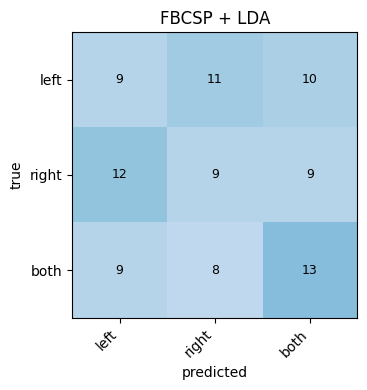

In [4]:
fig, ax = plt.subplots(figsize=(4, 4))
plot_confusion(np.array(result['confusion']), classes, ax=ax, title='FBCSP + LDA')
plt.tight_layout(); plt.show()

In [5]:
save_result('02_fbcsp', result, classes)
final = make_pipeline(k=8, n_components=4)
final.fit(X, y)
joblib.dump({'pipeline': final, 'classes': classes, 'bands': SUBBANDS},
            RESULTS_DIR / '02_fbcsp.joblib')
print('saved results + joblib')

Computing rank from data with rank=None


    Using tolerance 0.081 (2.2e-16 eps * 4 dim * 9.1e+13  max singular value)


    Estimated rank (data): 4


    data: rank 4 computed from 4 data channels with 0 projectors


Reducing data rank from 4 -> 4


...

Estimating class=1 covariance using LEDOIT_WOLF


Done.


Estimating class=2 covariance using LEDOIT_WOLF


Done.


saved results + joblib
